# **IMPORT**

Saving AmesHousing.csv to AmesHousing.csv
df shape: (2930, 82)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 1

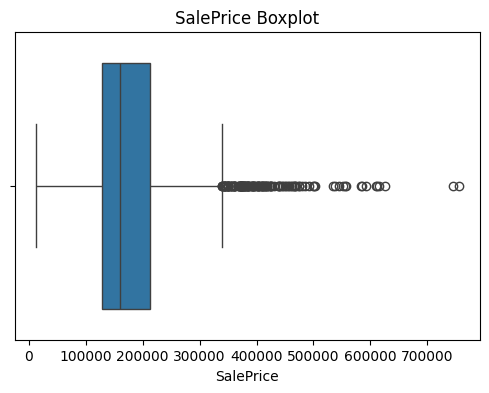

Saving AmesHousing.csv to AmesHousing (1).csv
df shape: (2930, 82)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   int64  
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object

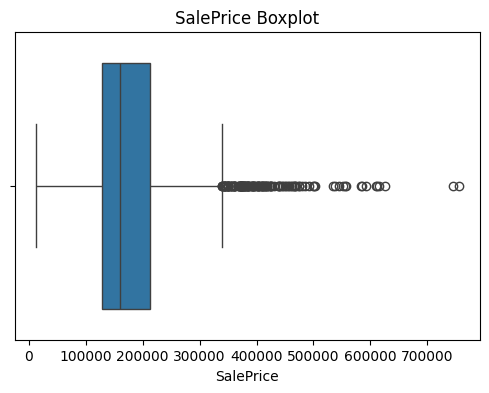

In [17]:
from cleaning_01 import clean_data

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from cleaning_01 import load_file, clean_data

--------------------------

# Loading the data

Saving AmesHousing.csv to AmesHousing (2).csv


Saving AmesHousing.csv to AmesHousing (3).csv
df shape: (2930, 82)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   int64  
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,1,IR1,Lvl,AllPub,...,0,0,0,0,0,5,2010,WD,Normal,215000.0
1,2,526350040,20,RH,80.0,11622,1,Reg,Lvl,AllPub,...,0,0,120,0,0,6,2010,WD,Normal,105000.0
2,3,526351010,20,RL,81.0,14267,1,IR1,Lvl,AllPub,...,0,0,0,0,12500,6,2010,WD,Normal,172000.0
3,4,526353030,20,RL,93.0,11160,1,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2010,WD,Normal,244000.0
4,5,527105010,60,RL,74.0,13830,1,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2010,WD,Normal,189900.0


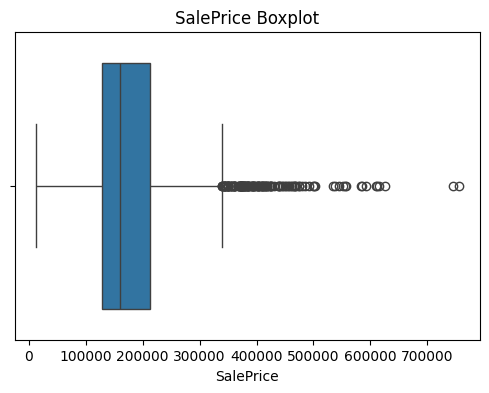

In [19]:
data = load_file("AmesHousing.csv")

cleaned_df = clean_data(data)

cleaned_df.head()

-----------------------------

# **One-hot encode**


I used **House Style** and **Sale Condition** because they are categorical columns with names, not numbers. I converted each category into separate 0/1 columns so the model can understand them. These columns may affect house price, so keeping their information is important.

In [20]:
def encode_two_categorical(df):
    df = df.copy()
    df = pd.get_dummies(df, columns=["House Style", "Sale Condition"])
    return df

In [21]:
df_encoded = encode_two_categorical(cleaned_df)
df_encoded.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,House Style_2.5Unf,House Style_2Story,House Style_SFoyer,House Style_SLvl,Sale Condition_Abnorml,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,1,526301100,20,RL,141.0,31770,1,IR1,Lvl,AllPub,...,False,False,False,False,False,False,False,False,True,False
1,2,526350040,20,RH,80.0,11622,1,Reg,Lvl,AllPub,...,False,False,False,False,False,False,False,False,True,False
2,3,526351010,20,RL,81.0,14267,1,IR1,Lvl,AllPub,...,False,False,False,False,False,False,False,False,True,False
3,4,526353030,20,RL,93.0,11160,1,Reg,Lvl,AllPub,...,False,False,False,False,False,False,False,False,True,False
4,5,527105010,60,RL,74.0,13830,1,IR1,Lvl,AllPub,...,False,True,False,False,False,False,False,False,True,False


--------------------------

# Ordinal Encoding


I used **Heating QC** because its values have a natural order from poor to excellent. Instead of treating them as plain text, I converted them into ranked numbers. This helps the model understand that some categories are better than others.

In [22]:
def encode_ordered_feature(df):
    df = df.copy()

    rank = {
        "Ex": 5,
        "Gd": 4,
        "TA": 3,
        "Fa": 2,
        "Po": 1
    }

    df["Heating QC Score"] = df["Heating QC"].replace(rank)
    return df

In [23]:
df_ord = encode_ordered_feature(cleaned_df)
df_ord.head()

/tmp/ipykernel_15006/2880893789.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Heating QC Score"] = df["Heating QC"].replace(rank)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice,Heating QC Score
0,1,526301100,20,RL,141.0,31770,1,IR1,Lvl,AllPub,...,0,0,0,0,5,2010,WD,Normal,215000.0,2
1,2,526350040,20,RH,80.0,11622,1,Reg,Lvl,AllPub,...,0,120,0,0,6,2010,WD,Normal,105000.0,3
2,3,526351010,20,RL,81.0,14267,1,IR1,Lvl,AllPub,...,0,0,0,12500,6,2010,WD,Normal,172000.0,3
3,4,526353030,20,RL,93.0,11160,1,Reg,Lvl,AllPub,...,0,0,0,0,4,2010,WD,Normal,244000.0,5
4,5,527105010,60,RL,74.0,13830,1,IR1,Lvl,AllPub,...,0,0,0,0,3,2010,WD,Normal,189900.0,4


----------------------------

# **Scale**


I scaled Lot Area and Gr Liv Area because both are numeric but have different ranges. Standardizing them makes the values comparable and prevents one column from dominating because of its larger scale. I used train/test scaling correctly to avoid data leakage.

In [24]:
def scale_numeric_features(df):
    df = df.copy()

    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    num_cols = ["Lot Area", "Gr Liv Area"]

    train_df[num_cols] = scaler.fit_transform(train_df[num_cols])
    test_df[num_cols] = scaler.transform(test_df[num_cols])

    return train_df, test_df

In [25]:
train_df, test_df = scale_numeric_features(cleaned_df)

train_df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
381,382,527359050,20,RL,80.0,0.033810,1,Reg,Lvl,AllPub,...,0,0,0,0,0,6,2009,WD,Family,152000.0
834,835,906475070,60,RL,68.0,2.307082,1,IR2,Low,AllPub,...,0,0,225,0,0,6,2009,WD,Abnorml,185000.0
1898,1899,534429030,90,RL,70.0,-0.035514,1,Reg,Lvl,AllPub,...,0,0,0,0,0,3,2007,WD,Normal,101800.0
678,679,535451170,90,RL,60.0,-0.363746,1,Reg,Lvl,AllPub,...,0,0,0,0,0,6,2009,WD,Normal,90000.0
700,701,902109130,190,RM,63.0,-0.310697,1,Reg,Lvl,AllPub,...,148,0,0,0,0,10,2009,WD,Normal,94550.0


-------------------------

# Create 2 domain features

I created **area_per_room** to measure how much living area each room gets, which is more meaningful than area alone. I also created **baths_per_bedroom** to reflect comfort and house functionality. These engineered features describe the house better than the raw columns alone.

In [26]:
def safe_divide(numerator, denominator):
    return numerator / denominator.replace(0, np.nan)

def build_domain_features(df):
    data = df.copy()

    data["area_per_room"] = safe_divide(data["Gr Liv Area"], data["TotRms AbvGrd"]).fillna(0)
    data["baths_per_bedroom"] = safe_divide(
        data["Full Bath"] + data["Half Bath"] * 0.5,
        data["Bedroom AbvGr"]
    ).fillna(0)

    return data

In [27]:
df_domain = build_domain_features(cleaned_df)
df_domain[["area_per_room", "baths_per_bedroom"]].head()

,area_per_room,baths_per_bedroom
0,236.571429,0.333333
1,179.200000,0.500000
2,221.500000,0.500000
3,263.750000,0.833333
4,271.500000,0.833333


-------------------------------

# Create 1 interaction feature


I created **house_value_score** by combining **Overall Qual** with **Gr Liv Area** because house value is often shaped by both quality and size together. Looking at one of them alone may not fully describe the property. This interaction feature captures that combined effect in a simple and useful way.

In [28]:
def make_interaction_feature(df):
    df = df.copy()
    df["house_value_score"] = df["Overall Qual"] * df["Gr Liv Area"]
    return df

In [29]:
df_interaction = make_interaction_feature(cleaned_df)
df_interaction[["Overall Qual", "Gr Liv Area", "house_value_score"]].head()

,Overall Qual,Gr Liv Area,house_value_score
0,6,1656,9936
1,5,896,4480
2,6,1329,7974
3,7,2110,14770
4,5,1629,8145


-----------------------------------

# Log-transform


I applied a **log transform** to Lot Area because this feature usually has a skewed distribution with a few very large values. The transformation reduces the effect of those extreme values and makes the distribution more balanced. This can improve both interpretation and model performance.

In [30]:
def log_transform_skewed_column(df):
    df = df.copy()

    plt.figure(figsize=(6,4))
    plt.hist(df["Lot Area"], bins=30)
    plt.title("Lot Area Before Log Transform")
    plt.xlabel("Lot Area")
    plt.ylabel("Frequency")
    plt.show()

    df["Lot Area Log"] = np.log1p(df["Lot Area"])

    plt.figure(figsize=(6,4))
    plt.hist(df["Lot Area Log"], bins=30)
    plt.title("Lot Area After Log Transform")
    plt.xlabel("Lot Area Log")
    plt.ylabel("Frequency")
    plt.show()

    return df

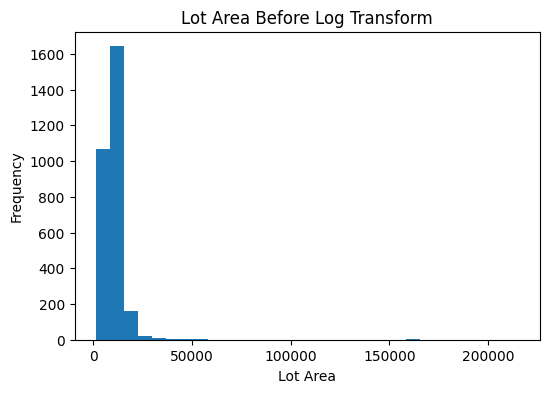

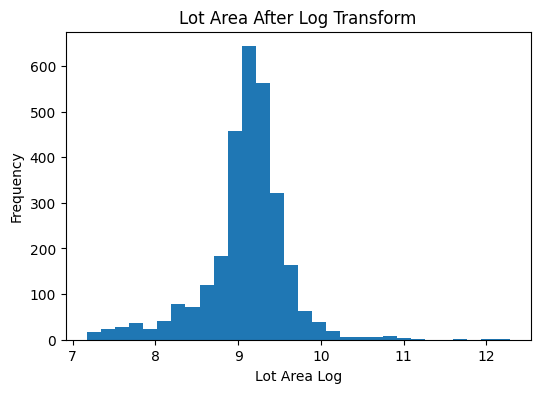

,Lot Area,Lot Area Log
0,31770,10.366309
1,11622,9.360741
2,14267,9.565775
3,11160,9.320181
4,13830,9.534668


In [31]:
df_log = log_transform_skewed_column(cleaned_df)
df_log[["Lot Area", "Lot Area Log"]].head()

--------------------------------

# Bin


I used **Year Built** to create house age groups because grouped categories are easier to interpret than raw year values. After converting the year into age, I divided houses into age ranges such as new, middle-aged, and old. This makes the feature more meaningful and easier to use in analysis.

In [32]:
def group_house_age(df):
    df = df.copy()

    house_age = 2026 - df["Year Built"]

    df["House Age Group"] = pd.cut(
        house_age,
        bins=[0, 15, 40, 200],
        labels=["New", "Middle-Aged", "Old"]
    )

    return df

In [33]:
df_binned = group_house_age(cleaned_df)
df_binned[["Year Built", "House Age Group"]].head()

,Year Built,House Age Group
0,1960,Old
1,1961,Old
2,1958,Old
3,1968,Old
4,1997,Middle-Aged


------------------------------

# Remove redundant features


I checked correlations between numeric columns to identify features that carry nearly the same information. When two columns are extremely similar, keeping both can add unnecessary complexity. For that reason, I removed highly correlated columns to make the dataset cleaner and more efficient.

In [34]:
def drop_high_correlation(df, threshold=0.95):
    df = df.copy()

    numeric_df = df.select_dtypes(include=["number"])
    corr_matrix = numeric_df.corr().abs()

    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    cols_to_drop = [
        column for column in upper_triangle.columns
        if (upper_triangle[column] > threshold).any()
    ]

    reduced_df = df.drop(columns=cols_to_drop)

    return reduced_df, cols_to_drop

In [35]:
df_reduced, dropped_features = drop_high_correlation(cleaned_df)

print("Dropped columns:", dropped_features)
df_reduced.head()

Dropped columns: ['Yr Sold']


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,1,IR1,Lvl,AllPub,...,62,0,0,0,0,0,5,WD,Normal,215000.0
1,2,526350040,20,RH,80.0,11622,1,Reg,Lvl,AllPub,...,0,0,0,120,0,0,6,WD,Normal,105000.0
2,3,526351010,20,RL,81.0,14267,1,IR1,Lvl,AllPub,...,36,0,0,0,0,12500,6,WD,Normal,172000.0
3,4,526353030,20,RL,93.0,11160,1,Reg,Lvl,AllPub,...,0,0,0,0,0,0,4,WD,Normal,244000.0
4,5,527105010,60,RL,74.0,13830,1,IR1,Lvl,AllPub,...,34,0,0,0,0,0,3,WD,Normal,189900.0


-------------------------------------

# Run


I used run_phase2() to combine all feature engineering steps into one clear pipeline. This makes the workflow more organized, easier to repeat, and simpler to review. In the end, it returns a final dataset that is ready for saving or for use in a machine learning model.

In [36]:
def run_phase2(df):
    df = encode_two_categorical(df)

    df = encode_ordered_feature(df)

    df = build_domain_features(df)

    df = make_interaction_feature(df)

    df = log_transform_skewed_column(df)

    df = group_house_age(df)

    train_df, test_df = scale_numeric_features(df)

    df_reduced, dropped_features = drop_high_correlation(df)

    print("Dropped columns:", dropped_features)
    print("Final shape:", df_reduced.shape)

    return df_reduced, train_df, test_df, dropped_features

Saving AmesHousing.csv to AmesHousing (4).csv


Saving AmesHousing.csv to AmesHousing (5).csv
df shape: (2930, 82)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   int64  
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object

/tmp/ipykernel_15006/2880893789.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Heating QC Score"] = df["Heating QC"].replace(rank)


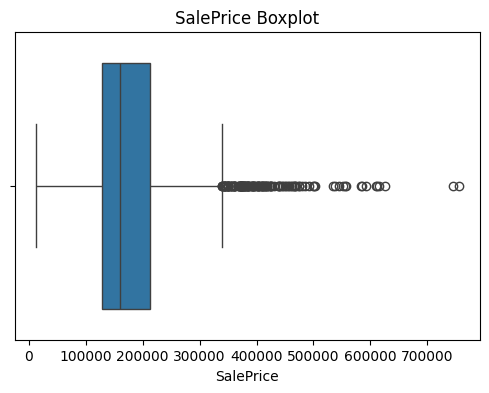

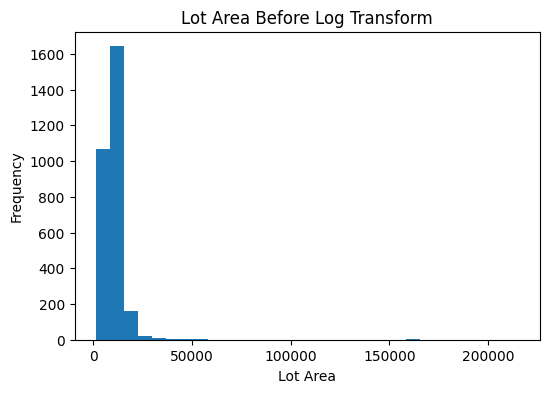

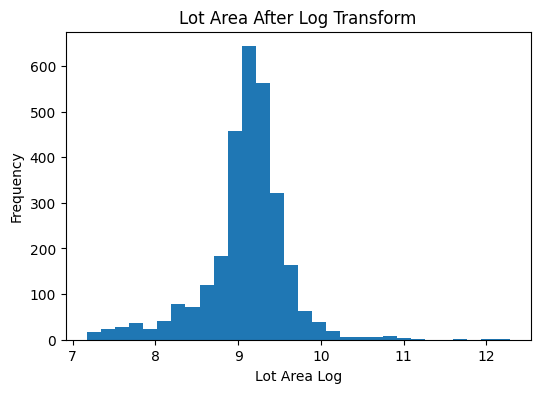

Dropped columns: ['Yr Sold']
Final shape: (2930, 95)


In [37]:
data = load_file("AmesHousing.csv")

cleaned_df = clean_data(data)

cleaned_df.head()

df_phase2, train_df, test_df, dropped_features = run_phase2(cleaned_df)

-----------------------------

# SAVE CSV

In [44]:
cleaned_df.to_csv('/content/cleaning1/cleaned_data.csv', index=False)

In [45]:
report_df = pd.DataFrame({
    'column': cleaned_df.columns,
    'dtype': cleaned_df.dtypes.astype(str),
    'missing_values': cleaned_df.isnull().sum().values
})

cleaned_df.to_csv('/content/cleaning1/cleaned_data.csv', index=False)
report_df.to_csv('/content/cleaning1/report.csv', index=False)

In [46]:
!ls /content/cleaning1

cleaned_data.csv  report.csv


------------------

# CHECKS

In [39]:
print("Shape:", df_phase2.shape)

print("\nBinned groups:")
print(df_phase2["House Age Group"].value_counts())

print("\nDropped columns:")
print(dropped_features)

print("\nScaled train mean:")
print(train_df[["Lot Area", "Gr Liv Area"]].mean())

print("\nLog column exists:", "Lot Area Log" in df_phase2.columns)
print("Interaction exists:", "house_value_score" in df_phase2.columns)
print("Ordinal exists:", "Heating QC Score" in df_phase2.columns)

Shape: (2930, 95)

Binned groups:
House Age Group
Old            1771
Middle-Aged    1159
New               0
Name: count, dtype: int64

Dropped columns:
['Yr Sold']

Scaled train mean:
Lot Area       4.850121e-17
Gr Liv Area    1.394410e-16
dtype: float64

Log column exists: True
Interaction exists: True
Ordinal exists: True
